In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


# PERSONA ENGINE

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/M2 SIR/PFE/segmented_users.csv")
df.head()


,user_id,age,wilaya,tariff,preferred_lang,mb_used,call_duration,sms_count,mb_per_month,price_da,...,plan_usage_rate,gb_norm,call_norm,sms_norm,user_score,user_type,cluster,pca1,pca2,segment
0,1,33,Souk Ahras,Gold 2000,FR,15936,45,29,30720,2000,...,0.518733,0.048148,0.047418,0.58,0.154300,Low,1,-0.506985,-1.100272,Balanced User
1,2,43,El Meniaa,Gold 2500,AR_LIT,15498,225,6,51200,2500,...,0.302689,0.046817,0.237092,0.12,0.118536,Low,1,-0.986294,-1.044608,Balanced User
2,3,55,Ouled Djellal,Gold 2000,AR_LATIN,3407,783,5,30720,2000,...,0.110901,0.010304,0.825079,0.10,0.272676,Medium,2,-1.725101,0.610125,Voice Heavy User
3,4,20,Ouargla,Switch 4000,FR,169446,84,0,256000,4000,...,0.661896,0.512022,0.088514,0.00,0.282565,Medium,0,2.477189,0.031023,Digital Heavy User
4,5,73,In Guezzam,Switch 2500,FR,8034,701,19,122880,2500,...,0.065380,0.024291,0.738672,0.38,0.309747,Medium,2,-1.308366,1.127379,Voice Heavy User


In [3]:
def generate_persona(row):

    segment = row['segment']
    age = row['age']

    # DIGITAL HEAVY USERS
    if segment == "Digital Heavy User":

        if age < 30:
            return "Young Digital User"
        else:
            return "Digital Heavy User"

    # VOICE HEAVY USERS
    elif segment == "Voice Heavy User":

        if age < 30:
            return "Young Voice User"
        else:
            return "Voice Heavy User"

    # BALANCED USERS
    elif segment == "Balanced User":

        if age < 30:
            return "Young Balanced User"
        else:
            return "Balanced User"

    return "General User"


# APPLY PERSONA GENERATION
df['persona'] = df.apply(
    generate_persona,
    axis=1
)

# SHOW RESULTS
print(
    df[['segment', 'age', 'persona']].head(20)
)

# SAVE NEW DATASET
df.to_csv(
    "/content/drive/MyDrive/M2 SIR/PFE/segmented_users_with_persona.csv",
    index=False
)

print("✅ Persona dataset saved successfully.")

               segment  age              persona
0        Balanced User   33        Balanced User
1        Balanced User   43        Balanced User
2     Voice Heavy User   55     Voice Heavy User
3   Digital Heavy User   20   Young Digital User
4     Voice Heavy User   73     Voice Heavy User
5        Balanced User   37        Balanced User
6     Voice Heavy User   66     Voice Heavy User
7        Balanced User   44        Balanced User
8        Balanced User   52        Balanced User
9   Digital Heavy User   26   Young Digital User
10       Balanced User   29  Young Balanced User
11    Voice Heavy User   61     Voice Heavy User
12    Voice Heavy User   48     Voice Heavy User
13    Voice Heavy User   73     Voice Heavy User
14    Voice Heavy User   74     Voice Heavy User
15    Voice Heavy User   58     Voice Heavy User
16  Digital Heavy User   33   Digital Heavy User
17    Voice Heavy User   64     Voice Heavy User
18  Digital Heavy User   33   Digital Heavy User
19    Voice Heavy Us

In [4]:
persona_stats = (
    df.groupby('persona')
      .agg({
          'gb_used':'mean',
          'call_duration':'mean',
          'sms_count':'mean',
          'price_da':'mean'
      })
      .round(2)
)

persona_stats

,gb_used,call_duration,sms_count,price_da
persona,,,,
Balanced User,21.79,196.60,20.83,1517.07
Digital Heavy User,169.58,183.47,27.48,3309.28
Voice Heavy User,18.04,616.01,27.61,2050.57
Young Balanced User,28.85,80.92,24.35,1413.14
Young Digital User,170.62,78.08,25.79,3121.22


In [5]:
print("\n===== STATISTIQUES GLOBALES =====")

print(f"Nombre total d'utilisateurs : {len(df)}")
print(f"Age moyen : {df['age'].mean():.2f} ans")
print(f"Age minimum : {df['age'].min()} ans")
print(f"Age maximum : {df['age'].max()} ans")
print(f"Nombre de personas : {df['persona'].nunique()}")


===== STATISTIQUES GLOBALES =====
Nombre total d'utilisateurs : 13711
Age moyen : 46.54 ans
Age minimum : 18 ans
Age maximum : 75 ans
Nombre de personas : 5


# LLM

Fine-tuned LLM for personalized telecom SMS generation using customer personas, offers and communication styles.

# Model Setup

Load Mistral-7B-Instruct using the Unsloth framework and fine-tuned with LoRA (Low-Rank Adaptation) for efficient personalized SMS generation.

In [ ]:
!pip install -q unsloth
!pip install -q transformers trl peft accelerate datasets bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 915.6/915.6 MB 182.7 MB/s eta 0:00:01

In [8]:
import unsloth
import transformers
import trl

print("✅ Unsloth OK")
print("✅ Transformers OK")
print("✅ TRL OK")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
✅ Unsloth OK
✅ Transformers OK
✅ TRL OK


In [10]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA RTX PRO 6000 Blackwell Server Edition


In [ ]:
from unsloth import FastLanguageModel

max_seq_length = 2048

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/mistral-7b-bnb-4bit",
    max_seq_length=max_seq_length,
    dtype=None,
    load_in_4bit=True,
)

print("✅ Mistral Loaded")

==((====))==  Unsloth 2026.6.7: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/4.13G [00:00<?, ?B/s]

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,

    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],

    lora_alpha=16,
    lora_dropout=0,
    bias="none",

    use_gradient_checkpointing="unsloth",

    random_state=3407,
)

print("✅ LoRA Ready")

Unsloth 2026.6.7 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


✅ LoRA Ready


# Test Dataset 1

In [ ]:
import pandas as pd
import json

df = pd.read_csv(
    "/content/drive/MyDrive/M2 SIR/PFE/sms_training_dataset.csv"
)

training_data = []

for _, row in df.iterrows():

    prompt = f"""
Persona: {row['persona']}
Language: {row['langue']}
Offer: {row['offre']}
Price: {row['prix_da']} DA
Tone: {row['ton']}
"""

    training_data.append({
        "text":
        f"""<s>[INST]
{prompt}
Generate one personalized telecom SMS.
[/INST]
{row['sms']}
</s>"""
    })

with open("/content/drive/MyDrive/M2 SIR/PFE/sms_lora_dataset.jsonl", "w", encoding="utf-8") as f:

    for item in training_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("✅ JSONL dataset created")
print("Total examples:", len(training_data))

In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files="/content/drive/MyDrive/M2 SIR/PFE/sms_lora_dataset.jsonl"
)

print(dataset)

In [ ]:
from transformers import TrainingArguments
import torch

training_args = TrainingArguments(
    output_dir="sms_mistral",

    num_train_epochs=3,

    per_device_train_batch_size=2,

    gradient_accumulation_steps=4,

    learning_rate=2e-4,

    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),

    logging_steps=10,

    optim="adamw_8bit",

    weight_decay=0.01,

    lr_scheduler_type="linear",

    report_to="none",
)

print("✅ Training Args Ready")

In [ ]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset["train"],
    dataset_text_field="text",
    max_seq_length=2048,
    args=training_args,
)

print("✅ Trainer Ready")

In [ ]:
trainer.train()

In [ ]:
model.save_pretrained(
    "/content/drive/MyDrive/M2 SIR/PFE/mistral_sms_model"
)

tokenizer.save_pretrained(
    "/content/drive/MyDrive/M2 SIR/PFE/mistral_sms_model"
)

print("✅ Model Saved")

Daridja

In [ ]:
prompt = """
Persona: Young Digital User
Language: AR_LATIN
Offer: 20Go Internet
Price: 1000 DA
Tone: Young

Generate one personalized telecom SMS.
"""

inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to("cuda")

outputs = model.generate(
    **inputs,
    max_new_tokens=80,
    temperature=0.7,
    do_sample=True
)

print(
    tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )
)

# Amelioration de dataset

In [ ]:
import pandas as pd
import json

df = pd.read_csv(
    "/content/drive/MyDrive/M2 SIR/PFE/sms_dataset_v2.csv"
)

training_data = []

for _, row in df.iterrows():

    prompt = f"""
Persona: {row['persona']}
Language: {row['langue']}
Offer: {row['offre']}
Price: {row['prix_da']} DA
Tone: {row['ton']}
"""

    training_data.append({
        "text":
        f"""<s>[INST]
{prompt}
Generate one personalized telecom SMS.
[/INST]
{row['sms']}
</s>"""
    })

with open("/content/drive/MyDrive/M2 SIR/PFE/sms_lora_datasetV2.jsonl", "w", encoding="utf-8") as f:

    for item in training_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("✅ JSONL dataset created")
print("Total examples:", len(training_data))

In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files="/content/drive/MyDrive/M2 SIR/PFE/sms_lora_datasetV2.jsonl"
)

print(dataset)

In [ ]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset["train"],
    dataset_text_field="text",
    max_seq_length=2048,
    args=training_args,
)

print("✅ Trainer Ready")

In [ ]:
trainer.train()

In [ ]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="sms_mistral/checkpoint-45",
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True,
)

FastLanguageModel.for_inference(model)

In [ ]:
prompt = """
Generate one telecom SMS.

Persona: Young Digital User
Language: FR
Offer: TikTok 20Go
Price: 500 DA
Tone: Young

Requirements:
- 15 to 25 words.
- Mention offer and price.
- Adapt to persona.
- Return SMS only.
"""

In [ ]:
inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to("cuda")

outputs = model.generate(
    **inputs,
    max_new_tokens=50,
    do_sample=True,
    temperature=0.8,
    top_p=0.9,
    repetition_penalty=1.1,
    pad_token_id=tokenizer.eos_token_id,
)

generated = outputs[0][inputs["input_ids"].shape[1]:]

sms = tokenizer.decode(
    generated,
    skip_special_tokens=True
)

print("\nSMS généré :")
print(sms)

**sauvegarde le modèle**

In [ ]:
import os

save_path = "/content/drive/MyDrive/M2 SIR/PFE/LLM_Model"

os.makedirs(save_path, exist_ok=True)

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"✅ Modèle sauvegardé dans : {save_path}")

In [ ]:
!ls "/content/drive/MyDrive/M2 SIR/PFE/LLM_Model"

# Tester le model

In [ ]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="/content/drive/MyDrive/M2 SIR/PFE/LLM_Model",
    max_seq_length=2048,
    load_in_4bit=True,
)

FastLanguageModel.for_inference(model)

print("✅ Modèle chargé")

In [ ]:
import torch

def generate_sms(persona, language, offer, price, tone):

    prompt = f"""
You are a telecom marketing expert.

Write ONE telecom SMS.

Persona: {persona}
Language: {language}
Offer: {offer}
Price: {price}
Tone: {tone}

Rules:
- One SMS only.
- No explanations.
- No instructions.
- No tags.
- No [INST].
- No Generate one telecom SMS.
- Between 15 and 30 words.
- Mention offer and price.
- Adapt to persona.
- Use natural telecom marketing language.
- Start directly with the SMS.
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=60,
        do_sample=True,
        temperature=1.0,
        top_p=0.95,
        repetition_penalty=1.2,
        pad_token_id=tokenizer.eos_token_id,
    )

    generated = outputs[0][inputs["input_ids"].shape[1]:]

    sms = tokenizer.decode(
        generated,
        skip_special_tokens=True
    )

    return sms.strip()


# Test
sms = generate_sms(
    persona="Digital Heavy User",
    language="FR",
    offer="40Go Internet",
    price="1000 DA",
    tone="Energetic"
)

print("SMS généré :")
print(sms)

In [ ]:
sms = generate_sms(
    persona="Digital Heavy User",
    language="FR",
    offer="40Go Internet",
    price="1000 DA",
    tone="Energetic"
)

print("SMS généré :")
print(sms)

In [ ]:
tests = [
    ("Digital Heavy User","FR","40Go Internet","1000 DA","Energetic"),
    ("Young Digital User","FR","TikTok 20Go","500 DA","Young"),
    ("Voice Heavy User","FR","1000 Minutes Tous Réseaux","900 DA","Professional"),
    ("Low Engagement User","FR","20Go Bonus","1000 DA","Reactivation"),
    ("Inactive Young User","FR","Pack Gaming 70Go","1600 DA","Young"),
    ("Digital Heavy User","AR_LATIN","50Go Internet","1200 DA","Energetic"),
]


for persona, language, offer, price, tone in tests:

    sms = generate_sms(
        persona,
        language,
        offer,
        price,
        tone
    )

    print("="*80)
    print("Persona :", persona)
    print("SMS :", sms)


# Dataset Improvement (Version 3)

The dataset was enriched by adding new personalization attributes such as customer **name**, city, usage profile and **message style**. **More SMS variations**, languages and marketing expressions were also introduced to improve diversity and model generalization.

In [ ]:
import pandas as pd

# Charger le dataset
file_path = "/content/drive/MyDrive/M2 SIR/PFE/sms_dataset_v3.csv"

df = pd.read_csv(file_path)

print("Nombre de lignes avant :", len(df))

# Supprimer les doublons complets
df = df.drop_duplicates()

print("Nombre de lignes après :", len(df))

# Sauvegarder dans le même fichier
df.to_csv(file_path, index=False, encoding="utf-8-sig")

print("✅ Dataset nettoyé et sauvegardé.")
df.head()

Nombre de lignes avant : 738
Nombre de lignes après : 737
✅ Dataset nettoyé et sauvegardé.


,persona,language,offer,price,tone,firstname,city,usage,message_style,sms
0,Digital Heavy User,FR,Pack Streaming 450Go,8900,Premium,Karim,Alger,Streaming,Entertainment,"Karim, profitez du Pack Streaming 450Go à seul..."
1,Voice Heavy User,FR,12000 Minutes Tous Réseaux,6600,Professional,Rachid,Oran,Calls,Connection,"Rachid, restez proche de vos collègues, amis e..."
2,Balanced User,FR,200Go + 2800 Minutes,6500,Friendly,Nadia,Annaba,Mixed,Balance,"Nadia, profitez de 200Go Internet et 2800 minu..."
3,Young Digital User,FR,TikTok Creator 220Go,4700,Young,Asma,Blida,Social Media,Creator,"Asma, créez davantage de vidéos et suivez les ..."
4,Digital Heavy User,AR_LIT,500 جيغا إنترنت,9900,Premium,محمد,وهران,Streaming,Benefit,محمد، استمتع بـ500 جيغا إنترنت مقابل 9900 دج ف...


In [ ]:
# Supprimer la colonne city si elle existe
if "city" in df.columns:
    df = df.drop(columns=["city"])
    print("Colonne 'city' supprimée")
else:
    print("Colonne 'city' introuvable")

df.to_csv(
    file_path,
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ Dataset sauvegardé")

print("\nNouvelles colonnes :")
print(df.columns.tolist())

print("\nAperçu du dataset :")
display(df.head())

Colonne 'city' supprimée

✅ Dataset sauvegardé

Nouvelles colonnes :
['persona', 'language', 'offer', 'price', 'tone', 'firstname', 'usage', 'message_style', 'sms']

Aperçu du dataset :


,persona,language,offer,price,tone,firstname,usage,message_style,sms
0,Digital Heavy User,FR,Pack Streaming 450Go,8900,Premium,Karim,Streaming,Entertainment,"Karim, profitez du Pack Streaming 450Go à seul..."
1,Voice Heavy User,FR,12000 Minutes Tous Réseaux,6600,Professional,Rachid,Calls,Connection,"Rachid, restez proche de vos collègues, amis e..."
2,Balanced User,FR,200Go + 2800 Minutes,6500,Friendly,Nadia,Mixed,Balance,"Nadia, profitez de 200Go Internet et 2800 minu..."
3,Young Digital User,FR,TikTok Creator 220Go,4700,Young,Asma,Social Media,Creator,"Asma, créez davantage de vidéos et suivez les ..."
4,Digital Heavy User,AR_LIT,500 جيغا إنترنت,9900,Premium,محمد,Streaming,Benefit,محمد، استمتع بـ500 جيغا إنترنت مقابل 9900 دج ف...


# Dataset Creation

The training dataset was manually created and curated for this project.

Each SMS example was designed to represent realistic telecom marketing campaigns while covering multiple customer segments, communication styles and languages.

The dataset includes:
- French (FR)
- Algerian Darija (AR_LATIN)
- Arabic (AR_LIT)

Additional personalization attributes such as customer name, city, usage profile and message style were manually introduced to improve personalization capabilities.



# Tone and Message Style

The **tone** defines the communication tone of the SMS (e.g., Young, Professional, Friendly, Premium, Reactivation).

The **message_style** defines the marketing approach used in the message, such as Benefit, Reward, Trendy, Loyalty, Balance or Comeback, allowing the model to generate more diverse and personalized SMS content.

In [ ]:
import pandas as pd
import json

df = pd.read_csv(
    "/content/drive/MyDrive/M2 SIR/PFE/sms_dataset_v3.csv"
)

training_data = []

for _, row in df.iterrows():

    firstname = ""
    price = ""

    if "firstname" in df.columns and not pd.isna(row["firstname"]):
        firstname = str(row["firstname"]).strip()

    if "price" in df.columns and not pd.isna(row["price"]):
        price = str(row["price"]).strip()

    prompt = f"""
Persona: {row['persona']}
Language: {row['language']}
Offer: {row['offer']}
Tone: {row['tone']}
Usage: {row['usage']}
Message Style: {row['message_style']}
"""

    if price:
        prompt += f"\nPrice: {price}"

    if firstname:
        prompt += f"\nFirstname: {firstname}"

    training_example = f"""<s>[INST]
{prompt}

Generate exactly ONE telecom marketing SMS.

IMPORTANT RULES:

- Use ONLY the information provided.
- Never invent information.
- Never invent prices.
- Never invent internet volume.
- Never invent minutes.
- Never invent bonuses.
- Never invent promotions.
- Never invent package names.

PRICE RULE:
- If a Price field exists, mention it naturally.
- If Price does NOT exist, DO NOT mention:
  * DA
  * DZD
  * price
  * internet volume
  * Go
  * GB
  * minutes
  * numbers related to an offer

PERSONALIZATION RULE:
- If Firstname exists, you may personalize the SMS.
- If Firstname does not exist, generate a generic SMS.

OUTPUT RULE:
- Output ONLY the final SMS.
- No explanations.
- No labels.
- No metadata.
- No Persona.
- No Language.
- No Offer.
- No instructions.

[/INST]
{row['sms']}
</s>"""

    training_data.append({
        "text": training_example
    })

with open(
    "/content/drive/MyDrive/M2 SIR/PFE/sms_lora_datasetV3.jsonl",
    "w",
    encoding="utf-8"
) as f:

    for item in training_data:
        f.write(
            json.dumps(
                item,
                ensure_ascii=False
            ) + "\n"
        )

print("✅ JSONL dataset V3 created")
print("Total examples:", len(training_data))

print("\nExample:")
print(training_data[0]["text"][:1000])

✅ JSONL dataset V3 created
Total examples: 737

Example:
<s>[INST]

Persona: Digital Heavy User
Language: FR
Offer: Pack Streaming 450Go
Tone: Premium
Usage: Streaming
Message Style: Entertainment

Price: 8900
Firstname: Karim

Generate exactly ONE telecom marketing SMS.

IMPORTANT RULES:

- Use ONLY the information provided.
- Never invent information.
- Never invent prices.
- Never invent internet volume.
- Never invent minutes.
- Never invent bonuses.
- Never invent promotions.
- Never invent package names.

PRICE RULE:
- If a Price field exists, mention it naturally.
- If Price does NOT exist, DO NOT mention:
  * DA
  * DZD
  * price
  * internet volume
  * Go
  * GB
  * minutes
  * numbers related to an offer

PERSONALIZATION RULE:
- If Firstname exists, you may personalize the SMS.
- If Firstname does not exist, generate a generic SMS.

OUTPUT RULE:
- Output ONLY the final SMS.
- No explanations.
- No labels.
- No metadata.
- No Persona.
- No Language.
- No Offer.
- No instructio

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./sms_lora_v3",

    num_train_epochs=4,

    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,

    learning_rate=2e-4,

    logging_steps=10,

    save_strategy="no",

    fp16=False,
    bf16=True,

    report_to="none"
)

In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files="/content/drive/MyDrive/M2 SIR/PFE/sms_lora_datasetV3.jsonl"
)

print(dataset)

from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset["train"],
    dataset_text_field="text",
    max_seq_length=2048,
    args=training_args,
)

print("✅ Trainer Ready")


trainer.train()

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 737
    })
})


Unsloth: Tokenizing ["text"] (num_proc=52):   0%|          | 0/737 [00:00<?, ? examples/s]

✅ Trainer Ready


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 737 | Num Epochs = 4 | Total steps = 372
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 7,283,675,136 (0.58% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
10,1.008284
20,0.289079
30,0.221424
40,0.152798
50,0.145425
60,0.125147
70,0.119608
80,0.119929
90,0.113038
100,0.098592


TrainOutput(global_step=372, training_loss=0.10923005472267827, metrics={'train_runtime': 209.5846, 'train_samples_per_second': 14.066, 'train_steps_per_second': 1.775, 'total_flos': 4.562792884079002e+16, 'train_loss': 0.10923005472267827, 'epoch': 4.0})

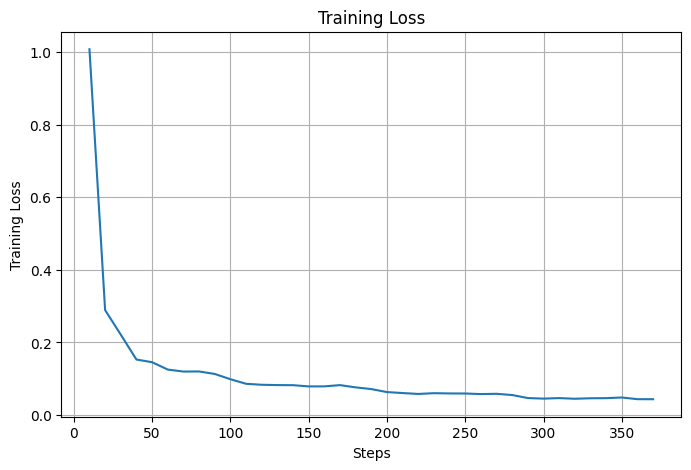

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

logs = pd.DataFrame(trainer.state.log_history)

logs.head()

plt.figure(figsize=(8,5))

plt.plot(
    logs["step"],
    logs["loss"]
)

plt.xlabel("Steps")
plt.ylabel("Training Loss")
plt.title("Training Loss")

plt.grid(True)

plt.show()

# save the model

In [ ]:
import os

save_path = "/content/drive/MyDrive/M2 SIR/PFE/LLM_Model_V3"

os.makedirs(save_path, exist_ok=True)

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("✅ Modèle sauvegardé :", save_path)

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/M2 SIR/PFE/LLM_Model_V3/tokenizer_config.json.


✅ Modèle sauvegardé : /content/drive/MyDrive/M2 SIR/PFE/LLM_Model_V3


In [ ]:
!ls "/content/drive/MyDrive/M2 SIR/PFE/LLM_Model_V3"

ls: cannot access '/content/drive/MyDrive/M2 SIR/PFE/LLM_Model_V3': No such file or directory


In [ ]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="/content/drive/MyDrive/M2 SIR/PFE/LLM_Model_V3",
    max_seq_length=2048,
    load_in_4bit=True,
)

FastLanguageModel.for_inference(model)

print("✅ Model loaded")

ModuleNotFoundError: No module named 'unsloth'

In [ ]:
def generate_sms(
    persona,
    language,
    offer,
    price="",
    tone="",
    firstname="",
    usage="",
    message_style=""
):

    prompt = f"""[INST]
Persona: {persona}
Language: {language}
Offer: {offer}
Tone: {tone}
Usage: {usage}
Message Style: {message_style}
"""

    if price:
        prompt += f"\nPrice: {price}"

    if firstname:
        prompt += f"\nFirstname: {firstname}"

    prompt += """

Generate one telecom marketing SMS.
[/INST]
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to("cuda")

    outputs = model.generate(
        **inputs,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.2,
        pad_token_id=tokenizer.eos_token_id
    )

    generated = outputs[0][inputs["input_ids"].shape[1]:]

    sms = tokenizer.decode(
        generated,
        skip_special_tokens=True
    )

    return sms.strip()

In [ ]:
print(
    generate_sms(
        persona="Young Digital User",
        language="FR",
        offer="TikTok Creator 220Go",
        price="4700 DA",
        tone="Young",
        firstname="Asma",
        usage="Social Media",
        message_style="Creator"
    )
)

/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


Asma, profitez de 220Go dédiés à TikTok à seulement 4700 DA pour créer et partager encore plus.


In [ ]:
print(
    generate_sms(
        persona="Inactive Young User",
        language="FR",
        offer="Découvrez les offres YOOZ",
        price="",
        tone="Friendly",
        firstname="",
        usage="Entertainment",
        message_style="Discovery"
    )
)

Découvrez les offres YOOZ et choisissez celle qui vous ressemble le plus.


In [ ]:
print(
    generate_sms(
        persona="Young Digital User",
        language="FR",
        offer="TikTok",
        price="",
        tone="Young",
        firstname="Malak",
        usage="Social Media",
        message_style="Creator"
    )
)

Malak, reste au cœur des tendances avec TikTok et partage tes vidéos préférées directement sur les réseaux sociaux.


In [ ]:
print(
    generate_sms(
        persona="Young Digital User",
        language="FR",
        offer="Visitez notre site web",
        price="",
        tone="Young",
        firstname="",
        usage="Social Media",
        message_style="Discovery"
    )
)

Explorez nos offres et profitez d'une expérience mobile adaptée à votre style.


In [ ]:
print(
    generate_sms(
        persona="Balanced User",
        language="FR",
        offer="Nouvelles offres Ooredoo",
        price="",
        tone="Friendly",
        firstname="",
        usage="Mixed",
        message_style="Discovery"
    )
)

Consultez les nouvelles offres Ooredoo et choisissez celle qui correspond à vos besoins.


In [ ]:
# TEST 5 PROMPTS - NO PRICE / NO GO

tests = [

    {
        "persona": "Balanced User",
        "language": "FR",
        "offer": "Nouvelles offres Ooredoo",
        "price": "",
        "tone": "Friendly",
        "firstname": "",
        "usage": "Mixed",
        "message_style": "Discovery"
    },

    {
        "persona": "Young Digital User",
        "language": "FR",
        "offer": "Instagram",
        "price": "",
        "tone": "Young",
        "firstname": "",
        "usage": "Social Media",
        "message_style": "Creator"
    },

    {
        "persona": "Digital Heavy User",
        "language": "FR",
        "offer": "Netflix",
        "price": "",
        "tone": "Premium",
        "firstname": "",
        "usage": "Streaming",
        "message_style": "Entertainment"
    },

    {
        "persona": "Young Digital User",
        "language": "AR_LATIN",
        "offer": "TikTok",
        "price": "",
        "tone": "Young",
        "firstname": "",
        "usage": "Social Media",
        "message_style": "Trendy"
    },

]

for i, test in enumerate(tests, start=1):

    print("=" * 80)
    print(f"TEST {i}")
    print("=" * 80)

    sms = generate_sms(
        persona=test["persona"],
        language=test["language"],
        offer=test["offer"],
        price=test["price"],
        tone=test["tone"],
        firstname=test["firstname"],
        usage=test["usage"],
        message_style=test["message_style"]
    )

    print("INPUT:")
    print(test)

    print("\nGENERATED SMS:")
    print(sms)

    print("\n")

TEST 1
INPUT:
{'persona': 'Balanced User', 'language': 'FR', 'offer': 'Nouvelles offres Ooredoo', 'price': '', 'tone': 'Friendly', 'firstname': '', 'usage': 'Mixed', 'message_style': 'Discovery'}

GENERATED SMS:
Consultez les nouvelles offres Ooredoo disponibles dès maintenant sur notre site.


TEST 2
INPUT:
{'persona': 'Young Digital User', 'language': 'FR', 'offer': 'Instagram', 'price': '', 'tone': 'Young', 'firstname': '', 'usage': 'Social Media', 'message_style': 'Creator'}

GENERATED SMS:
Partage tes meilleurs moments, échange avec ta communauté et découvre de nouvelles inspirations sur Instagram.


TEST 3
INPUT:
{'persona': 'Digital Heavy User', 'language': 'FR', 'offer': 'Netflix', 'price': '', 'tone': 'Premium', 'firstname': '', 'usage': 'Streaming', 'message_style': 'Entertainment'}

GENERATED SMS:
Profite de tes séries et films préférés quand tu le souhaites et découvre toujours plus of new stories.


TEST 4
INPUT:
{'persona': 'Young Digital User', 'language': 'AR_LATIN', 'o

# Tets  

In [ ]:
!pip install -q nltk rouge-score

In [ ]:
from nltk.translate.bleu_score import sentence_bleu
from rouge_score import rouge_scorer
import pandas as pd

In [ ]:
test_df = df.sample(
    n=100,
    random_state=42
).reset_index(drop=True)

print("Nombre de tests :", len(test_df))

test_df.head(20)

Nombre de tests : 100


,persona,language,offer,price,tone,firstname,usage,message_style,sms
0,Digital Heavy User,AR_LIT,الجيل الخامس,NaN,Premium,محمد,Technology,Innovation,محمد، جرّب الجيل الخامس واستمتع بتجربة رقمية ج...
1,Balanced User,FR,Facebook,NaN,Friendly,NaN,Mixed,Social,Découvre les actualités qui t'intéressent et p...
2,Promotion,FR,Pack Streaming 500Go,9900,Marketing,NaN,Streaming,Promotion,Regardez davantage de films et séries grâce à ...
3,Young Digital User,FR,YOOZ 200Go,4200,Young,Asma,Social Media,Discovery,"Asma, découvrez YOOZ 200Go à seulement 4200 DA..."
4,Balanced User,AR_LATIN,180Go + 2500 Minutes,6200,Friendly,Amel,Mixed,DailyUse,180Go internet w 2500 minute b 6200 DA seuleme...
5,Promotion,AR_LIT,Instagram Creator 180Go,3900,Marketing,NaN,Social Media,Creator,شارك المزيد من الصور والفيديوهات مع 180 جيغا إ...
6,Balanced User,FR,YOOZ,NaN,Friendly,NaN,Daily Use,Discovery,Personnalise ton expérience mobile et profite ...
7,Promotion,FR,Instagram Creator 180Go,3900,Marketing,NaN,Social Media,Creator,Partagez vos meilleurs moments avec 180Go Inte...
8,Promotion,AR_LIT,YouTube 180Go,3900,Marketing,NaN,Entertainment,Discovery,شاهد المزيد من الفيديوهات مع 180 جيغا إنترنت م...
9,Balanced User,AR_LATIN,180Go + 2500 Minutes,6200,Friendly,NaN,Mixed,Balance,180Go internet w 2500 minute b 6200 DA seuleme...


In [ ]:
generated_sms = []

for _, row in test_df.iterrows():

    sms = generate_sms(
        persona=row["persona"],
        language=row["language"],
        offer=row["offer"],
        price="" if pd.isna(row["price"]) else str(row["price"]),
        tone=row["tone"],
        firstname="" if pd.isna(row["firstname"]) else str(row["firstname"]),
        usage=row["usage"],
        message_style=row["message_style"]
    )

    generated_sms.append(sms)

test_df["generated_sms"] = generated_sms

/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


In [ ]:
for i in range(20):

    print("=" * 80)

    print("REFERENCE:")
    print(test_df.loc[i, "sms"])

    print("\nGENERATED:")
    print(test_df.loc[i, "generated_sms"])

    print("\n")

REFERENCE:
محمد، جرّب الجيل الخامس واستمتع بتجربة رقمية جديدة.

GENERATED:
محمد، اكتشف الجيل الخامس وابقَ على أطلس الإنترنت.


REFERENCE:
Découvre les actualités qui t'intéressent et partage tes expériences avec ton entourage.

GENERATED:
Partage tes expériences, reste connecté à ta communauté et échange facilement avec ton entourage.


REFERENCE:
Regardez davantage de films et séries grâce à 500Go Internet à seulement 9900 DA.

GENERATED:
Profitez de 500Go Internet à seulement 9900 DA pour vos films et séries préférés.


REFERENCE:
Asma, découvrez YOOZ 200Go à seulement 4200 DA et personnalisez votre expérience mobile selon vos envies.

GENERATED:
Asma, découvrez YOOZ 200Go à seulement 4200 DA et personnalisez votre expérience mobile selon vos envies.


REFERENCE:
180Go internet w 2500 minute b 6200 DA seulement fi offre complète.

GENERATED:
Amel, profite de 180Go internet w 2500 minute b 6200 DA seulement fi offre wa7da complète.


REFERENCE:
شارك المزيد من الصور والفيديوهات مع 180 

In [ ]:
from nltk.translate.bleu_score import sentence_bleu
from rouge_score import rouge_scorer

bleu_scores = []

rouge1_scores = []
rougeL_scores = []

scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rougeL"],
    use_stemmer=True
)

for _, row in test_df.iterrows():

    reference = row["sms"]
    generated = row["generated_sms"]

    bleu = sentence_bleu(
        [reference.split()],
        generated.split()
    )

    bleu_scores.append(bleu)

    rouge = scorer.score(
        reference,
        generated
    )

    rouge1_scores.append(
        rouge["rouge1"].fmeasure
    )

    rougeL_scores.append(
        rouge["rougeL"].fmeasure
    )

avg_bleu = sum(bleu_scores) / len(bleu_scores)

avg_rouge1 = sum(rouge1_scores) / len(rouge1_scores)

avg_rougeL = sum(rougeL_scores) / len(rougeL_scores)

print(f"BLEU     : {avg_bleu:.4f}")
print(f"ROUGE-1  : {avg_rouge1:.4f}")
print(f"ROUGE-L  : {avg_rougeL:.4f}")

BLEU     : 0.4239
ROUGE-1  : 0.6629
ROUGE-L  : 0.6350


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

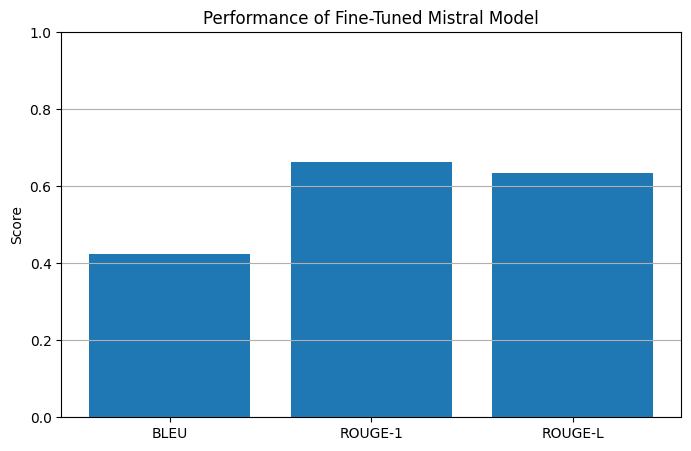

In [ ]:
import matplotlib.pyplot as plt

scores = {
    "BLEU": avg_bleu,
    "ROUGE-1": avg_rouge1,
    "ROUGE-L": avg_rougeL
}

plt.figure(figsize=(8,5))

plt.bar(
    scores.keys(),
    scores.values()
)

plt.title(
    "Performance of Fine-Tuned Mistral Model"
)

plt.ylabel(
    "Score"
)

plt.ylim(0, 1)

plt.grid(
    axis="y"
)

plt.show()

In [ ]:
results = pd.DataFrame({
    "Metric": ["BLEU", "ROUGE-1", "ROUGE-L"],
    "Score": [
        avg_bleu,
        avg_rouge1,
        avg_rougeL
    ]
})

results

,Metric,Score
0,BLEU,0.423872
1,ROUGE-1,0.662866
2,ROUGE-L,0.635019


# Interface

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
import pandas as pd
import torch

import pandas as pd
import re

def generate_sms(
    persona,
    language,
    offer,
    price,
    tone,
    firstname="",
    usage="",
    message_style=""
):

    firstname = "" if pd.isna(firstname) else str(firstname).strip()

    prompt = f"""
You are an Ooredoo telecom SMS marketing assistant.

Generate exactly ONE SMS.

Rules:
- Return ONLY the final SMS.
- No explanations.
- No examples.
- No labels.
- No Persona.
- No Language.
- No Offer.
- No Price.
- No instructions.
- No [INST].
- No HTML.
- No markdown.
- Maximum 30 words.

Persona: {persona}
Language: {language}
Offer: {offer}
Price: {price}
Tone: {tone}
Usage: {usage}
Message Style: {message_style}
"""

    if firstname:
        prompt += f"\nFirstname: {firstname}"

    prompt += "\n\nSMS:"

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to("cuda")

    outputs = model.generate(
        **inputs,
        do_sample=True,
        temperature=0.8,
        top_p=0.9,
        repetition_penalty=1.2,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    generated = outputs[0][inputs["input_ids"].shape[1]:]

    sms = tokenizer.decode(
        generated,
        skip_special_tokens=True
    )

    # CLEANING
    bad_patterns = [
        "[INST]",
        "[/INST]",
        "<s>",
        "</s>",
        "&nbsp;",
        "You are",
        "Generate exactly",
        "Generate one personalized telecom SMS",
        "Persona:",
        "Language:",
        "Offer:",
        "Price:",
        "Tone:",
        "Usage:",
        "Message Style:",
        "SMS:",
        "Example:",
        "In this example",
        "You can generate",
    ]

    for p in bad_patterns:
        sms = sms.replace(p, "")

    sms = sms.strip()

    # garder uniquement la première ligne
    sms = sms.split("\n")[0]

    # enlever guillemets
    sms = sms.replace('"', '')
    sms = sms.replace("'", "")

    # enlever espaces multiples
    sms = re.sub(r"\s+", " ", sms)

    return sms.strip()






# SINGLE SMS
def generate_single_sms(
    persona,
    language,
    offer,
    price,
    tone,
    firstname,
    usage,
    message_style
):

    firstname = "" if pd.isna(firstname) else str(firstname).strip()

    if firstname.lower() in [
        "nan",
        "null",
        "none"
    ]:
        firstname = ""

    return generate_sms(
        persona=persona,
        language=language,
        offer=offer,
        price=price,
        tone=tone,
        firstname=firstname,
        usage=usage,
        message_style=message_style
    )


# CSV GENERATION
def generate_csv(file):

    df = pd.read_csv(file.name)

    generated_sms = []

    for _, row in df.iterrows():

        firstname = ""

        if "firstname" in df.columns:

            if not pd.isna(row["firstname"]):

                firstname = str(row["firstname"]).strip()

                if firstname.lower() in [
                    "nan",
                    "null",
                    "none",
                    ""
                ]:
                    firstname = ""

        sms = generate_sms(
            persona=row["persona"],
            language=row["language"],
            offer=row["offer"],
            price=row["price"],
            tone=row["tone"],
            firstname=firstname,
            usage=row["usage"],
            message_style=row["message_style"]
        )

        generated_sms.append(sms)


    df["generated_sms"] = generated_sms

    df = df.fillna("")


    output_file = "/content/generated_sms.csv"

    df.to_csv(
        output_file,
        index=False,
        encoding="utf-8-sig"
    )

    return output_file, df

# OPTIONS
personas = [
    "Young Digital User",
    "Digital Heavy User",
    "Young Voice User",
    "Voice Heavy User",
    "Young Balanced User",
    "Balanced User"
]

languages = [
    "FR",
    "AR_LATIN",
    "AR_LIT"
]

tones = [
    "Young",
    "Premium",
    "Professional",
    "Friendly",
    "Exclusive"
]

usages = [
    "Streaming",
    "Social Media",
    "Gaming",
    "Family",
    "Business",
    "Downloads",
    "Entertainment",
    "Calls",
    "Daily Use",
    "Mixed"
]

styles = [
    "Trendy",
    "Benefit",
    "Lifestyle",
    "Connection",
    "Balance",
    "Reward",
    "Comeback",
    "Creator",
    "Discovery",
    "Professional",
    "Challenge",
    "Family",
    "Social",
    "Premium",
    "Innovation",
    "Comfort",
    "Emotion",
    "Curiosity",
    "Convenience",
    "DailyUse"
]


theme = gr.themes.Soft(
    primary_hue="red"
)

# UI
with gr.Blocks(theme=theme) as demo:

    gr.HTML("""
    <style>

    :root{
        --ooredoo-red:#e30613;
    }

    button{
        background:#e30613 !important;
        border:none !important;
    }

    button:hover{
        background:#c40011 !important;
    }

    h1{
        color:#e30613 !important;
    }

    .gr-button-primary{
        background:#e30613 !important;
    }

    </style>
    """)

    gr.Markdown("""
# 📱 Ooredoo AI SMS Generator

Generate personalized telecom marketing SMS using your fine-tuned LLM.
""")

    # TAB 1
    with gr.Tab("Single SMS"):

        persona = gr.Dropdown(
            personas,
            label="Persona"
        )

        language = gr.Dropdown(
            languages,
            label="Language"
        )

        offer = gr.Textbox(
            label="Offer"
        )

        price = gr.Textbox(
            label="Price"
        )

        tone = gr.Dropdown(
            tones,
            label="Tone"
        )

        firstname = gr.Textbox(
            label="Firstname (optional)"
        )

        usage = gr.Dropdown(
            usages,
            label="Usage"
        )

        message_style = gr.Dropdown(
            styles,
            label="Message Style"
        )

        generate_btn = gr.Button(
            "🚀 Generate SMS"
        )

        output_sms = gr.Textbox(
            label="Generated SMS",
            lines=6
        )

        generate_btn.click(
            fn=generate_single_sms,
            inputs=[
                persona,
                language,
                offer,
                price,
                tone,
                firstname,
                usage,
                message_style
            ],
            outputs=output_sms
        )

    # TAB 2

    with gr.Tab("CSV Batch Generation"):

        gr.Markdown(
            "Upload a CSV file containing persona, language, offer, price, tone, firstname, usage and message_style."
        )

        csv_file = gr.File(
            label="Upload CSV"
        )

        generate_csv_btn = gr.Button(
            "📂 Generate SMS For CSV"
        )

        output_csv = gr.File(
            label="Download Result CSV"
        )

        output_table = gr.Dataframe(
            label="Generated SMS Preview",
            interactive=False,
            wrap=True
        )

        generate_csv_btn.click(
            fn=generate_csv,
            inputs=csv_file,
            outputs=[
                output_csv,
                output_table
            ]
        )
demo.launch(
    share=True,
    debug=True
)

/tmp/ipykernel_65041/3495767956.py:275: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=theme) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://3a3633eaa47a0636ac.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^